In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'Sample - Superstore.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country     

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


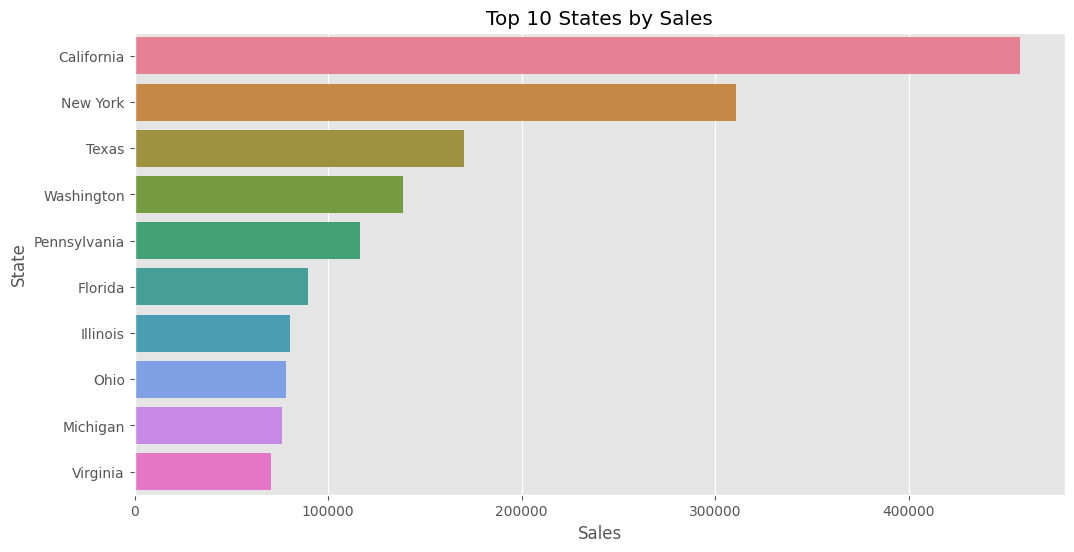

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,
    legend=False
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")
plt.show()

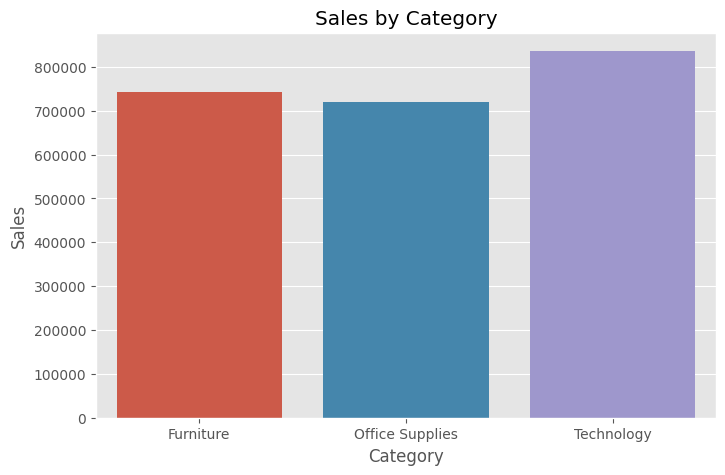

In [ ]:
plt.figure(figsize=(8,5))

sales = df.groupby("Category")["Sales"].sum().reset_index()

sns.barplot(
    data=sales,
    x="Category",
    y="Sales",
    hue="Category",
    legend=False
)

plt.title("Sales by Category")
plt.show()

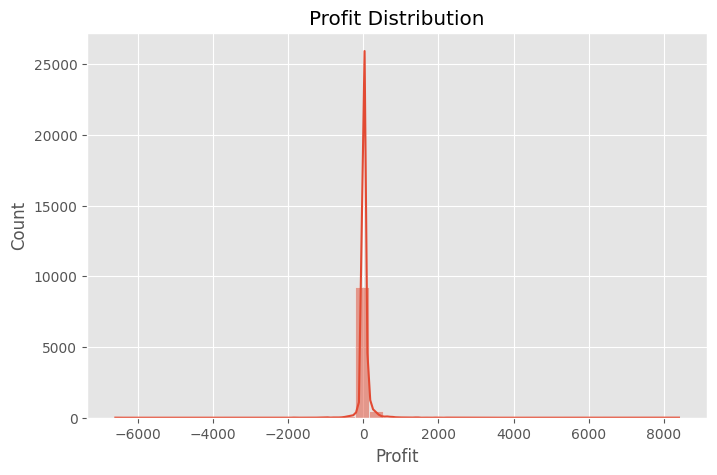

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=40, kde=True)

plt.title("Profit Distribution")
plt.show()

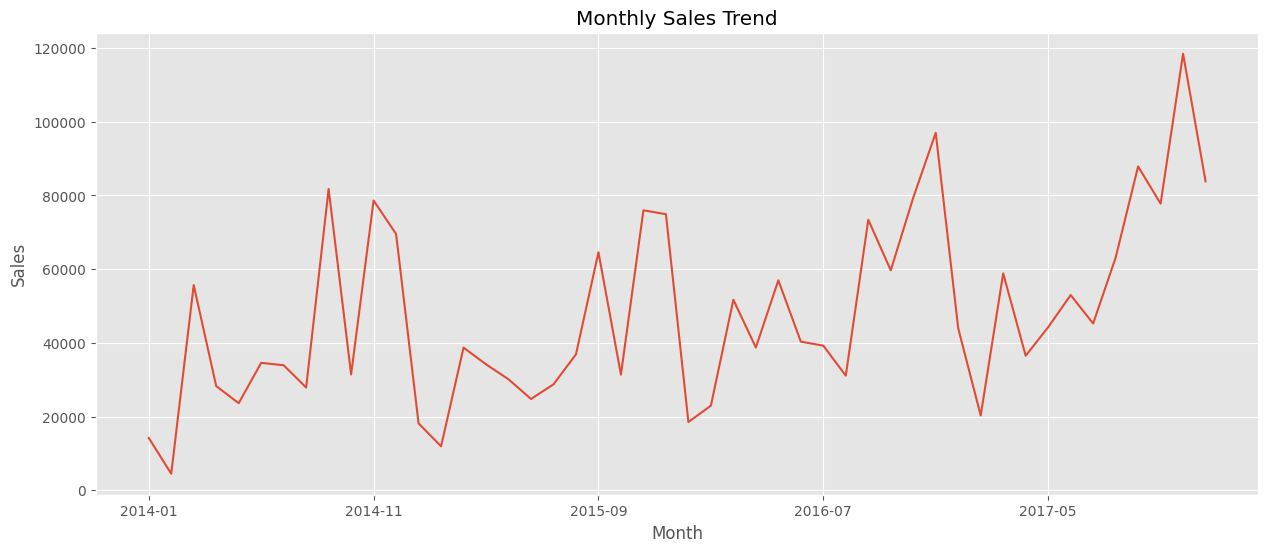

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(15,6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

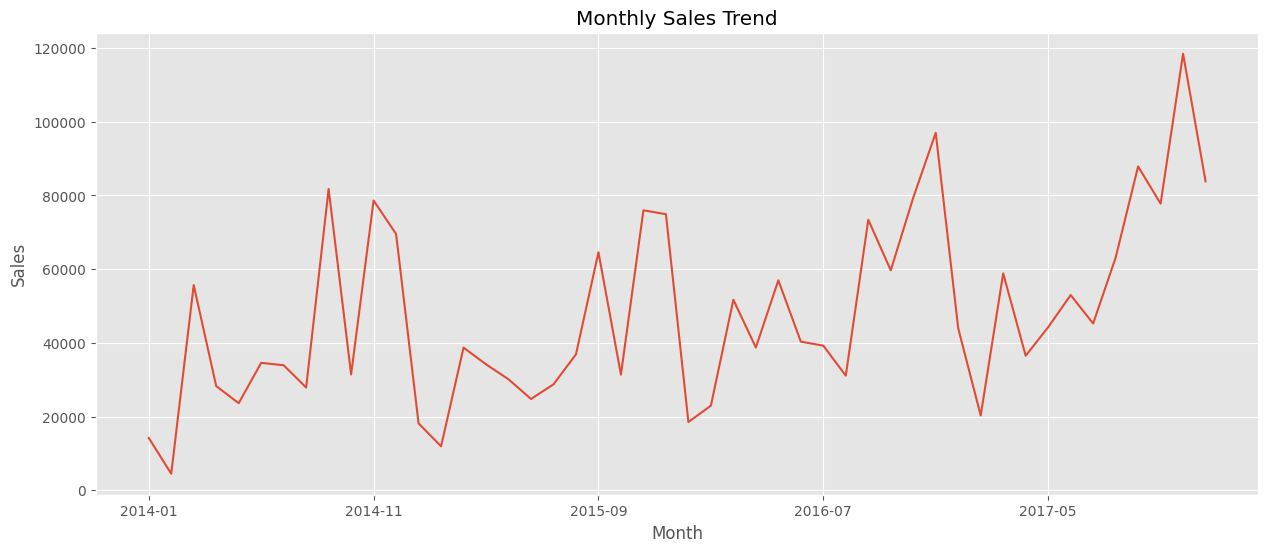

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(15,6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

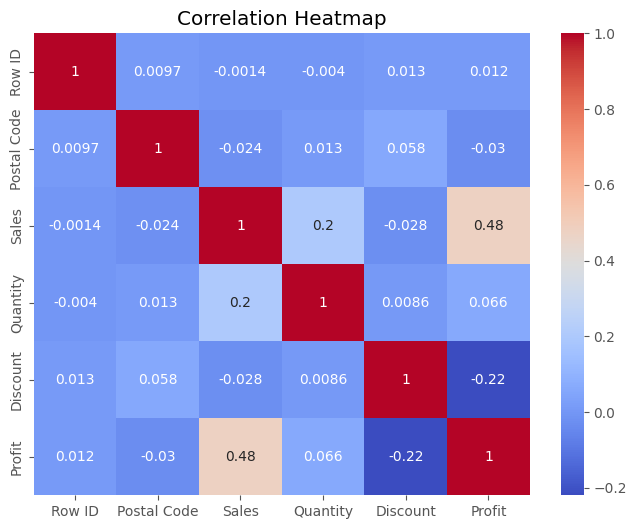

In [ ]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Business Insights

- Technology products contribute the highest sales.
- California is the highest revenue-generating state.
- Some transactions result in negative profits, indicating opportunities to optimize pricing and discount strategies.
- Sales fluctuate across months, suggesting seasonal trends.
- Correlation analysis helps identify relationships between Sales, Profit, Discount, and Quantity.